# The lucky number 8 — does Chinese superstition move the US tape? 🎴📈
### Prices *do* cluster — on the wrong number — and 8/8 gives one tiny, fragile tick you can't keep

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![8--clustering%3F: Busted](https://img.shields.io/badge/8--clustering%3F-Busted-8b949e?style=flat-square)

In Chinese culture **8** (八, *ba*) sounds like **發** (*fa*, "to prosper, get rich") and is wildly lucky; **4** (四) sounds like **死** ("death") and is shunned. This isn't just folklore — real finance papers find Chinese investors really do pile their orders onto 8-ending prices (and lose money doing it), and pay up for lucky listing digits. The most auspicious date of all is **8/8** — the reason the Beijing Olympics opened at 8:08 pm on 2008-08-08.

So here's the clean question: does any of that survive onto the **tradable US tape** — the last digit of US-listed Chinese stocks, and their returns around 8/8?

> 📓 **Plain-language layer.** Want the *t*-stats, the two-proportion digit test, the placebo and the jackknife? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 15 US-listed China ADRs vs 15 matched US large-caps (raw closing prices); the 8th of August each year 2005→2025 for a China ETF (`FXI`) vs emerging markets (`EEM`). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lucky_number_8 import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    REP = st.digit_report(PRICES)
else:
    PRICES = EV = INC = REP = None
print("real cache present:", HAVE_REAL, "| lucky dates:", len(data.LUCKY_DATES),
      "| resolved:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_dates': 21, 'n_included': 21, 'fp': 'd880312d91f3', 'panel_rows': 5465, 'span_lo': '2004-10-08', 'span_hi': '2026-06-30', 'day_mean': 0.387, 'day_t': 2.273, 'day_hit': 13, 'day_n': 21, 'day_wlo': 40.9, 'day_whi': 79.2, 'wk_mean': 0.295, 'wk_t': 0.693, 'wk_hit': 12, 'wk_n': 21, 'wk_wlo': 36.5, 'wk_whi': 75.5, 'pl_day_p': 0.043, 'pl_day_plmean': -0.005, 'pl_day_plsd': 0.224, 'pl_wk_p': 0.242, 'pl_wk_plmean': -0.03, 'pl_wk_plsd': 0.478, 'day_cap_g': 0.387, 'day_cap_n5': 0.287, 'day_cap_t5': 1.69, 'day_cap_n10': 0.187, 'day_cap_t10': 1.1, 'wk_cap_g': 0.295, 'wk_cap_n5': 0.195, 'wk_cap_t5': 0.46, 'wk_cap_n10': 0.095, 'wk_cap_t10': 0.22, 'jk_lo': 1.956, 'jk_hi': 2.806, 'jk_below2': 4, 'jk_n': 21, 'y2008_day': 2.263, 'y2008_wk': -3.688, 'car': {-5: 0.319, -4: 0.294, -3: 0.394, -2: 0.193, -1: 0.0, 0: 0.387, 1: 0.336, 2: 0.352, 3: 0.458, 4: 0.295, 5: 0.476}, 'synA_null_mean': -0.13, 'synA_null_sd': 1.52, 'synA_null_fire': 2, 'synA_seeds': 20, 'synA_p1_t': 2.49, 'synA_p2_t': 6.62, 'china_n': 45997, 'control_n': 82602, 'n_china': 15, 'n_control': 15, 'china_freq': [12.286, 9.655, 9.531, 9.546, 9.703, 10.331, 9.627, 9.64, 9.909, 9.772], 'control_freq': [11.014, 9.948, 9.771, 9.828, 9.669, 10.208, 9.907, 9.921, 9.762, 9.972], 'china_chi2': 289.6, 'control_chi2': 110.6, 'chi_crit': 16.919, 'z8_china': 9.909, 'z8_control': 9.762, 'z8_diff': 0.147, 'z8': 0.85, 'z8_p': 0.396, 'z4_china': 9.703, 'z4_control': 9.669, 'z4_diff': 0.034, 'z4': 0.2, 'z4_p': 0.845, 'z0_china': 12.286, 'z0_control': 11.014, 'z0_diff': 1.271, 'z0': 6.86, 'z0_p': 0.0, 'synB_null_fire': 0, 'synB_null_z8mean': -0.3, 'synB_p2_z8': 14.32, 'synB_p2_chi2': 384.8}


real cache present: True | lucky dates: 21 | resolved: 21


## The answer first

| Question | Answer |
|---|---|
| Do Chinese stocks' prices cluster on "8"? | **No** (on the US tape). China ADRs end in 8 **9.91%** of the time vs **9.76%** for US controls — statistically identical. |
| Do they avoid the "death" digit 4? | **No.** 9.70% vs 9.67% — no gap at all. |
| Do prices cluster on *anything*? | **Yes — on 0**, the plain round number, and China ADRs do it *more* (12.3% vs 11.0%). Round-number habit, not lucky-8 magic. |
| Does the market pop around 8/8? | **A tiny, fragile tick.** **+0.39%** on the day (*t* = 2.27) — but it leans on the 08/08/08 Olympics day itself, and dies once you pay to trade it. |

> The superstition is real in people's heads and in mainland order books. On the US exchange tape it barely leaves a fingerprint.

## 1 · The claim

> *"Chinese investors love 8 and hate 4. So Chinese stock prices bunch up on 8-ending numbers, dodge 4-ending ones, and get a wave of lucky-day buying around auspicious dates like 8/8."*

It rides on genuine research: Brown & Mitchell (2008) find 8-clustering in mainland Chinese order books; Bhattacharya et al. (2018) show Taiwanese retail traders pile onto 8-ending limit orders (and lose money); Hirshleifer, Jian & Zhang (2018) find Chinese IPOs with lucky digits are overpriced. All real — and almost all measured where humans *set* the price (order books, IPO offer prices). We test whether it reaches the **secondary US tape**, where global market-makers do the pricing.

## 2 · So what?

If the lucky-8 fingerprint showed up in US-listed prices, it would be a delightful proof that pure culture bleeds through an ocean and a different exchange into the numbers on your screen — and a 8/8 buying bump would be a free calendar trade (you always know when 8/8 is). If it *doesn't*, that's just as interesting: it tells you exactly where a behavioral bias lives — at the point of human price-setting — and where it gets arbitraged away.

## 3 · How would we even know?

- **The digits.** Take the raw closing price of 15 US-listed Chinese ADRs and 15 matched US large-caps, grab the **last cent digit** (`$27.38` → 8), and count. Both trade in penny ticks, so any 8-magic must show up as China having *more* 8s than the US control.
- **The date.** The 8th of August, one event per year 2005→2025, for a China ETF (`FXI`) minus emerging markets (`EEM`) — so we measure the *China-specific* move, not the whole EM tide.
- **The honesty checks.** A random-window placebo (does a random week do the same?), a jackknife (does one lucky year carry it?), and the actual cost of trading it. And two synthetic controls that prove the detectors fire when there really *is* an effect to find.

## 4 · The teardown — let's actually look

**First, the digits. If 8 were lucky here, the blue (China) bar at 8 would tower over the grey (US) one. Watch what actually happens.**

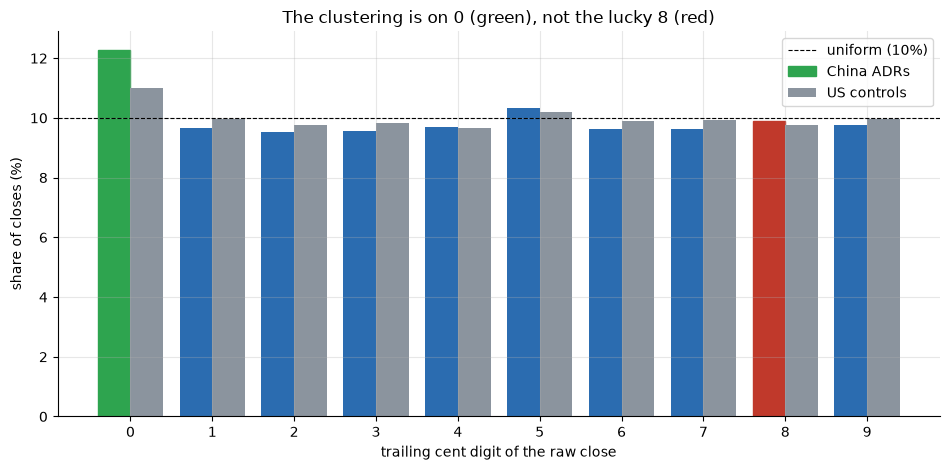

digit 8: China 9.91%  vs US 9.76%
digit 0: China 12.29%  vs US 11.01%


In [2]:
if HAVE_REAL:
    cf = [100*c/REP['china_n'] for c in REP['china_counts']]
    uf = [100*c/REP['control_n'] for c in REP['control_counts']]
else:
    cf, uf = R['china_freq'], R['control_freq']
x = np.arange(10); w = 0.4
fig, ax = plt.subplots(figsize=(9.6, 4.8))
b1 = ax.bar(x - w/2, cf, w, label='China ADRs', color='#2b6cb0')
ax.bar(x + w/2, uf, w, label='US controls', color=GREY)
ax.axhline(10, ls='--', c='k', lw=.8, label='uniform (10%)')
b1[8].set_color(RED); b1[0].set_color(GREEN)
ax.set_xticks(x); ax.set_xlabel('trailing cent digit of the raw close')
ax.set_ylabel('share of closes (%)')
ax.set_title('The clustering is on 0 (green), not the lucky 8 (red)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"digit 8: China {cf[8]:.2f}%  vs US {uf[8]:.2f}%")
print(f"digit 0: China {cf[0]:.2f}%  vs US {uf[0]:.2f}%")

There it is. The **8** bars are a dead heat — China **9.91%**, US **9.76%** — and neither basket dodges **4**. What towers instead is **0**: both baskets love prices ending in `.x0`, and the Chinese names love them *even more* (12.3% vs 11.0%). That's the universal round-number habit every market on Earth has (Harris, 1991) — not the lucky 8. The superstition's price fingerprint simply isn't on this tape.

**Now the date. Does `FXI` pop around 8/8, over and above emerging markets?**

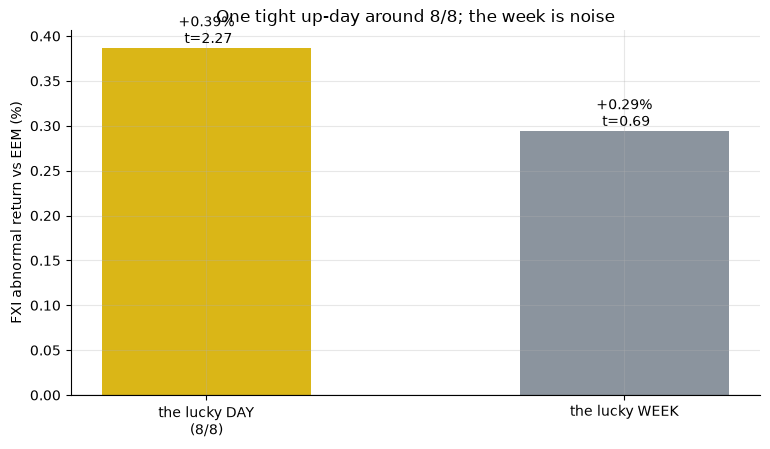

In [3]:
if HAVE_REAL:
    day = st.one_sample_t(INC['ar_day'].values)
    wk = st.one_sample_t(INC['ar_week'].values)
    dm, dt_, wm, wt = day['mean']*100, day['t'], wk['mean']*100, wk['t']
else:
    dm, dt_, wm, wt = R['day_mean'], R['day_t'], R['wk_mean'], R['wk_t']
fig, ax = plt.subplots(figsize=(7.8, 4.6))
bars = ax.bar(['the lucky DAY\n(8/8)', 'the lucky WEEK'], [dm, wm],
              color=[AMBER if abs(dt_)>=2 else GREY, GREY], width=.5)
for b, v, t in zip(bars, [dm, wm], [dt_, wt]):
    ax.annotate(f'{v:+.2f}%\n t={t:.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('FXI abnormal return vs EEM (%)')
ax.set_title('One tight up-day around 8/8; the week is noise')
plt.tight_layout(); plt.show()

The lucky **day** is up **+0.39%** vs emerging markets (*t* = 2.27) — that clears the desk's "probably not noise" bar. The lucky **week** is a shrug (+0.29%, *t* = 0.69). **But is that one good day carried by a single famous year?** We drop each of the 21 years one at a time:

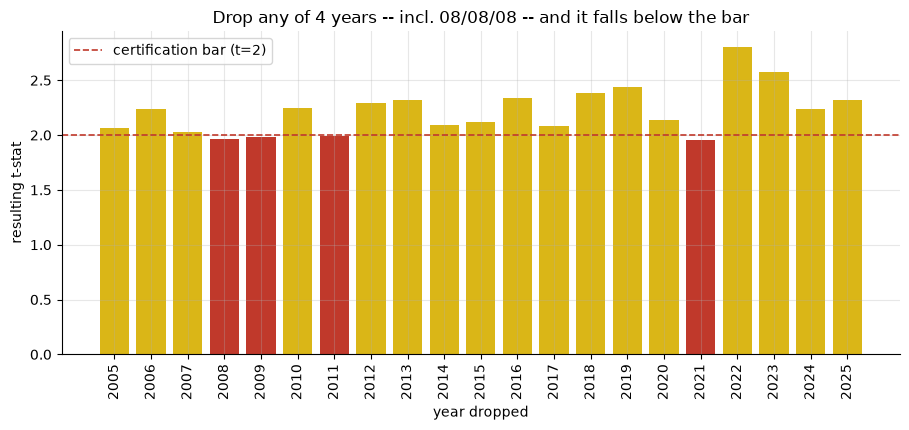

jackknife t range: [1.956, 2.806]


In [4]:
if HAVE_REAL:
    x = INC['ar_day'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
    yrs = INC['year'].values
else:
    rng = np.random.default_rng(743)
    jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n'])); yrs = range(2005, 2026)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if t < 2 else AMBER for t in jk]
ax.bar([str(y) for y in yrs], jk, color=cols)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar (t=2)')
ax.set_ylabel('resulting t-stat'); ax.set_xlabel('year dropped')
ax.tick_params(axis='x', rotation=90)
ax.set_title(f'Drop any of {R["jk_below2"]} years -- incl. 08/08/08 -- and it falls below the bar')
ax.legend(); plt.tight_layout(); plt.show()
print(f'jackknife t range: [{min(jk):.3f}, {max(jk):.3f}]')

**4 of 21** single-year removals push it below the bar — and one of them is **2008 itself**: the 08/08/08 triple-8 Olympics day was the best day in the sample (**+2.26%**), and leaning on the most photogenic date in the whole story is the opposite of robust. (That same 2008 lucky *week*? **-3.69%** — the pre-crisis China unwind was already running.)

**Finally — 8/8 is a date on the wall, so you could always trade it. Would it pay?**

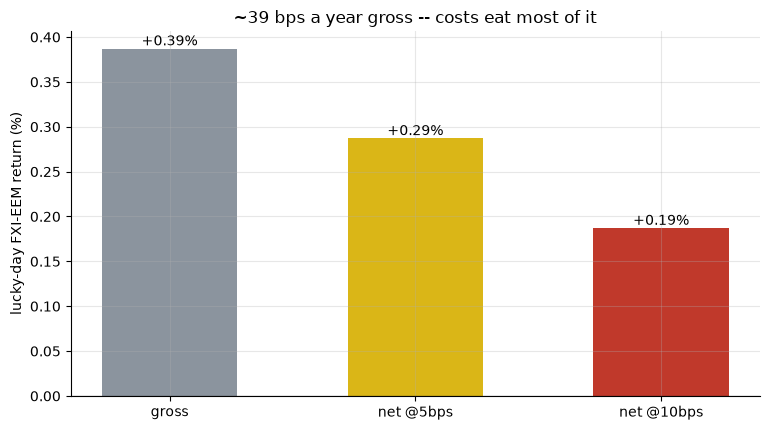

In [5]:
if HAVE_REAL:
    g = st.one_sample_t(INC['cap_day_gross'].values)['mean']*100
    n5 = st.one_sample_t(INC['cap_day_net'].values)['mean']*100
    EV10 = st.build_event_table(PRICES, cost_bps=10.0)
    n10 = st.one_sample_t(EV10[EV10['included']]['cap_day_net'].values)['mean']*100
else:
    g, n5, n10 = R['day_cap_g'], R['day_cap_n5'], R['day_cap_n10']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
bars = ax.bar(['gross', 'net @5bps', 'net @10bps'], [g, n5, n10],
              color=[GREY, AMBER, RED], width=.55)
for b, v in zip(bars, [g, n5, n10]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('lucky-day FXI-EEM return (%)')
ax.set_title('~39 bps a year gross -- costs eat most of it')
plt.tight_layout(); plt.show()

Gross, the lucky-day trade is **+0.39%** a year. Pay one realistic round trip (5 bps a side) and it's **+0.29%** (*t* = 1.69); at 10 bps, **+0.19%** (*t* = 1.10). Below the bar the moment you actually trade it. A tiny real tick — not a bankable edge.

## 5 · The verdict

- **Signal — Weak.** One real nominal hit (the 8/8 day, *t* = 2.27, placebo *p* = 0.043), but it's the only horizon that clears, it leans on the 08/08/08 Olympics day, and it dies net of costs.
- **Tradability — Mirage.** ~39 bps/yr gross does not survive a single round trip.
- **8-clustering? — Busted.** Chinese ADRs cluster no more on 8 than US stocks, and don't avoid 4. The clustering that exists is the universal round-number pull on 0.

## 6 · Going further 🚪

- **This is where a behavioral bias goes to hide.** The lucky-8 effect is well-documented where *humans set the price* — mainland limit orders, IPO offer prices. On the US secondary tape, where the price is made by market-makers and arbitrageurs, the fingerprint is gone. That's not a failure of the papers; it's a map of exactly where the bias lives.
- **Where it might still be alive:** mainland A-share tick data, Hong Kong limit-order books, or **IPO offer prices** (HK$8.80, HK$88.00 …) — the human-chosen numbers. That's the natural sequel, and it needs order-level data this study doesn't use.
- **Sibling studies:** the calendar-event engine is shared with [708-eurovision-effect](../../708-eurovision-effect/) and [707-plane-crash-effect](../../707-plane-crash-effect/); the folklore-calendar cousins are [158-super-bowl](../../158-super-bowl/) and [234-olympic-year](../../234-olympic-year/).

*Think the lucky 8 IS on the tape somewhere? Bring order-book or IPO-offer data and show a China-specific 8-excess that survives a round-number control. We'll publish the teardown.*